In [4]:
import kagglehub
import numpy as np
import struct
from array import array
import sys
import random
import os
import matplotlib.pyplot as plt
from os.path import join

In [5]:
np.random.seed(42)

In [6]:
sys.path.append("../src/")
import nn

In [7]:
try:
    os.makedirs("../data/MNIST/")
    path = kagglehub.dataset_download("hojjatk/mnist-dataset", output_dir="../data/MNIST")
except:
    pass

In [8]:
class MnistDataloader:
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

In [9]:
data_path = "../data/MNIST/"
training_images_filepath = data_path + "train-images.idx3-ubyte"
training_labels_filepath = data_path + "train-labels.idx1-ubyte"
test_images_filepath = data_path + "t10k-images.idx3-ubyte"
test_labels_filepath = data_path + "t10k-labels.idx1-ubyte"
DataLoader = MnistDataloader(training_images_filepath,
                             training_labels_filepath,
                             test_images_filepath,
                             test_labels_filepath)

In [10]:
training_set, testing_set = DataLoader.load_data()
x_train, y_train = training_set
x_test, y_test = testing_set

x_train = np.array(list(map(lambda x: np.array(x), x_train)))
x_test = np.array(list(map(lambda x: np.array(x), x_test)))

x_train = x_train.reshape(-1, 1, 28, 28) / 255.0
x_test = x_test.reshape(-1, 1, 28, 28) / 255.0

y_train = np.array(y_train).astype(int)
y_train = np.array(np.eye(10)[y_train])
y_test = np.array(y_test).astype(int)
y_test = np.array(np.eye(10)[y_test])

In [11]:
x_train.shape, y_train.shape

((60000, 1, 28, 28), (60000, 10))

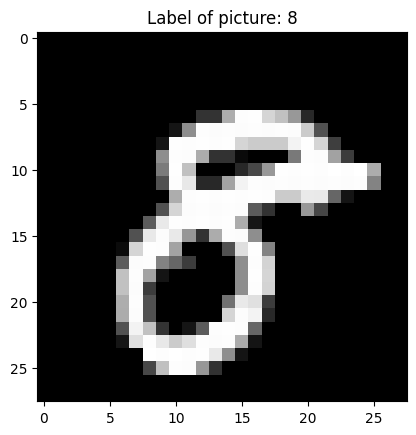

In [12]:
i = random.randint(0, 60000)
plt.title(f"Label of picture: {y_train[i].argmax()}")
plt.imshow(x_train[i][0], cmap="gray")

In [13]:
model = nn.NeuralNetwork(
    [
        nn.layers.Conv2d(1, 1, (3,3), stride=1, initializer=nn.utils.initializers.he_init),
        nn.activations.ReLU(),
        nn.layers.Pooling2d(2, 2),
        nn.layers.Flatten(),
        nn.layers.Linear(169, 100, initializer=nn.utils.initializers.he_init),
        nn.activations.ReLU(),
        nn.layers.Linear(100, 10, initializer=nn.utils.initializers.he_init)
        
    ],
    loss_fn = nn.losses.CrossEntropyWithLogits()
)

In [14]:
model.forward(np.random.randn(1, 10, 28, 28)).shape

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


(1, 10)

In [18]:
epochs = 10
lr = 1e-2
batch_size = 30

In [19]:
optim = nn.optim.SGD(model, lr)

In [ ]:
losses_train = np.zeros(epochs)
losses_test = np.zeros(epochs)

for epoch in range(epochs):
    loss_train = 0

    indices = np.random.permutation(len(x_train)).astype(int)
    x_train_shuffled = x_train[indices]
    y_train_shuffled = y_train[indices]

    for i in range(0, x_train.shape[0], batch_size):
        x_batch = x_train_shuffled[i: i+batch_size]
        y_batch = y_train_shuffled[i: i+batch_size]
        y_pred = model.forward(x_batch)
        loss, cache = model.loss_fn.forward(y_pred, y_batch)
        loss_train += loss * len(x_batch)
        model.backward(model.loss_fn.backward(cache))
        optim.step()
    loss_train = loss_train / (x_train.shape[0])
    losses_train[epoch] = loss_train

    loss_test, _ = model.loss_fn.forward(model.forward(x_test), y_test)
    losses_test[epoch] = loss_test

    print(f"Epoch {epoch + 1}, train loss {loss_train}, test loss {loss_test}")

Epoch 1, train loss 0.22234955948023058, test loss 0.19828355553461438
Epoch 2, train loss 0.19116043867846502, test loss 0.18200796553936419
Epoch 3, train loss 0.1716570022711428, test loss 0.16986907101411558
Epoch 4, train loss 0.1571181755225635, test loss 0.15323382044285044
Epoch 5, train loss 0.14650762591755842, test loss 0.1464272061141815
Epoch 6, train loss 0.1370674677556013, test loss 0.14452103995714127
Epoch 7, train loss 0.12932290115598716, test loss 0.1360630368766745
Epoch 8, train loss 0.12244879448349934, test loss 0.1369716172144273
Epoch 9, train loss 0.11636564759310092, test loss 0.1301379734269778
Epoch 10, train loss 0.11197608952383022, test loss 0.13468680742729253


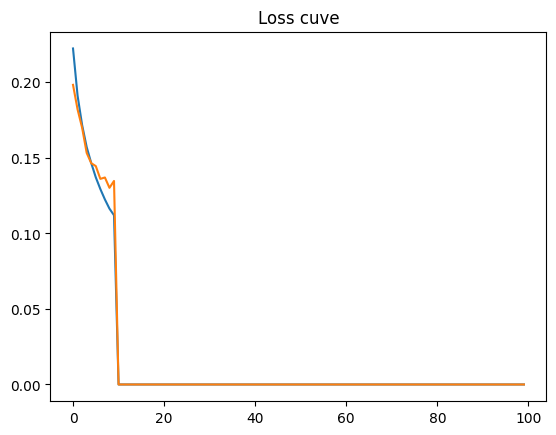

In [21]:
plt.title("Loss cuve")
plt.plot(losses_train, label="train")
plt.plot(losses_test, label="test")

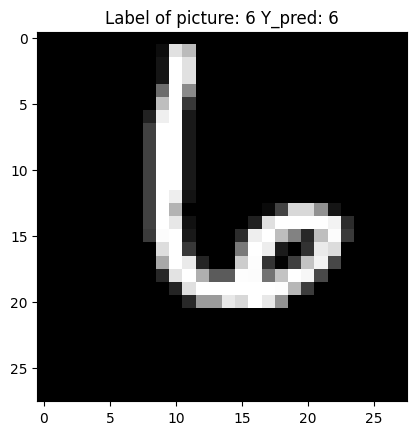

In [26]:
i = random.randint(0, x_test.shape[0])
x_sample = x_test[i]
y_pred = model.forward(np.array([x_sample]))
plt.title(f"Label of picture: {y_test[i].argmax()} Y_pred: {y_pred.argmax()}")
plt.imshow(x_test[i][0], cmap="gray")

In [27]:
def accuracy(y_pred, y_true):
    pred_labels = np.argmax(y_pred, axis=1)

    if y_true.ndim == 2:
        true_labels = np.argmax(y_true, axis=1)
    else:
        true_labels = y_true

    return np.mean(pred_labels == true_labels)

In [28]:
y_pred = model.forward(x_test)
accuracy(y_pred, y_test)

np.float64(0.9608)

In [29]:
y_pred = model.forward(x_train)
accuracy(y_pred, y_train)

np.float64(0.96645)

array([[[[0.14594674, 0.24979003, 0.15532176],
         [1.27479385, 1.75402351, 1.34731492],
         [1.89065096, 2.59516858, 1.84716586]]]])